# 02. ORE Snapshot and Its Abilities

This notebook shifts from a hand-built snapshot to a loader-backed snapshot built from a fresh ORE run. The goal is
to make the snapshot itself feel like the primary artifact: something you can inspect, audit, serialize, and hand to
both Python and ORE code without reopening the raw files.

**Purpose**
- show what the loader actually materializes
- keep the data fresh by generating the ORE outputs inside the notebook run
- introduce the stricter parity-grade `OreSnapshot` audit

**What you will learn**
- what comes back from `XVALoader.from_files(...)`
- how to inspect trades, quotes, netting, and generated XML without digging through the repo tree
- how to tell whether the resulting case is parity-ready


In [7]:
from pathlib import Path
import os
import sys

def _find_repo_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in (current, *current.parents):
        if (candidate / "Tools" / "PythonOreRunner" / "notebook_series" / "series_helpers.py").exists():
            return candidate
    repo_hint = Path("/Users/gordonlee/Documents/Engine")
    if (repo_hint / "Tools" / "PythonOreRunner" / "notebook_series" / "series_helpers.py").exists():
        return repo_hint
    raise RuntimeError("Could not locate the Engine repo root from the current notebook working directory")

REPO_ROOT = _find_repo_root(Path.cwd())
NOTEBOOK_DIR = REPO_ROOT / "Tools" / "PythonOreRunner" / "notebook_series"
for path in (NOTEBOOK_DIR, REPO_ROOT):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

os.environ.setdefault("MPLCONFIGDIR", "/tmp/codex-mplconfig")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import series_helpers as nh

try:
    from IPython.display import display
except Exception:
    def display(obj):
        if hasattr(obj, "to_string"):
            print(obj.to_string())
        else:
            print(obj)

repo = nh.bootstrap_notebook_env(REPO_ROOT)
nh.apply_plot_style()
print(repo)
RUN_ORE_SWIG = os.getenv("RUN_ORE_SWIG_DEMOS") == "1"


/Users/gordonlee/Documents/Engine


Fresh run root: /Users/gordonlee/Documents/Engine/Tools/PythonOreRunner/notebook_series/_fresh_runs/notebook_02_1773231602000
Fresh ORE xml: /Users/gordonlee/Documents/Engine/Tools/PythonOreRunner/notebook_series/_fresh_runs/notebook_02_1773231602000/Input/ore.xml
Fresh output dir: /Users/gordonlee/Documents/Engine/Tools/PythonOreRunner/notebook_series/_fresh_runs/notebook_02_1773231602000/Output


,component,count,notes
0,market quotes,7881,2016-02-05
1,fixings,5454,file
2,trades,1,file
3,netting sets,3,EUR
4,collateral balances,0,2016-02-05
5,analytics,1,CVA


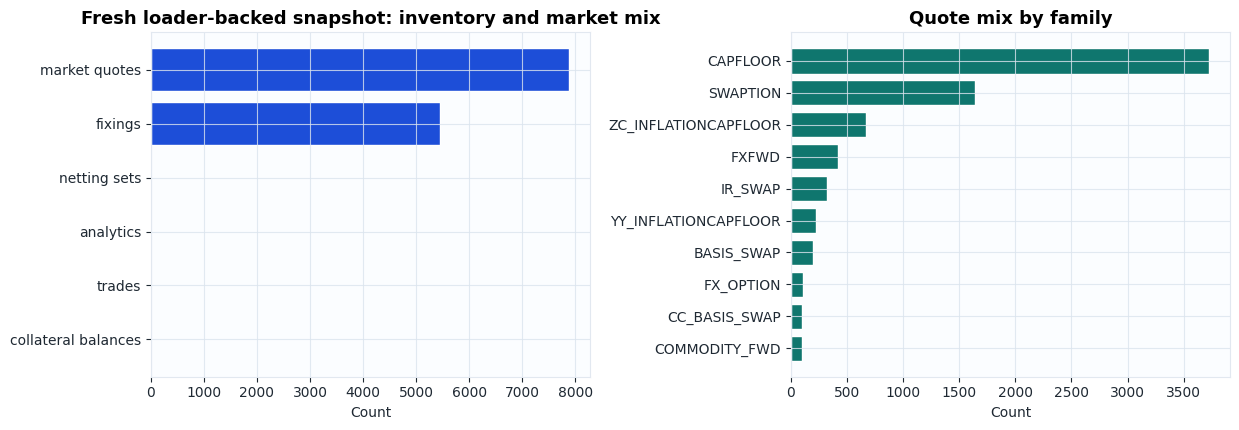

In [8]:
from native_xva_interface import map_snapshot, DeterministicToyAdapter

# Run ORE now, then load the fresh inputs and outputs into Python-facing snapshot objects.
snapshot, ore_snapshot, fresh_meta = nh.load_fresh_case_snapshots("flat_EUR_5Y_A", label="notebook_02")
mapped = map_snapshot(snapshot)

print("Fresh run root:", fresh_meta["run_root"])
print("Fresh ORE xml:", fresh_meta["ore_xml"])
print("Fresh output dir:", fresh_meta["output_dir"])
display(nh.snapshot_overview(snapshot))
nh.plot_snapshot_composition(snapshot, title="Fresh loader-backed snapshot: inventory and market mix")


## Inputs we reuse from the repo

The notebook starts from the aligned benchmark case but does not trust its checked-in outputs. Instead it executes a
new ORE run first and only then loads the results. That means the portfolio, curves, exposure files, and XVA outputs
shown below are all from the current run.

The loader-backed path still follows the same code used in the tests and demos:
- `native_xva_interface/loader.py`
- `native_xva_interface/tests/test_step2_loader.py`
- `native_xva_interface/tests/test_step3_merge.py`


,trade_id,trade_type,counterparty,netting_set,product_type,currency_or_pair,notional,maturity_years
0,SWAP_EUR_5Y_A_flat,Swap,CPTY_A,CPTY_A,IRS,EUR,10000000.0,4.999316


,netting_set_id,counterparty,active_csa,csa_currency,threshold_pay,threshold_receive
0,CPTY_A,None,False,EUR,0.0,0.0
1,CPTY_B,None,False,EUR,0.0,0.0
2,CPTY_C,None,False,EUR,0.0,0.0


""


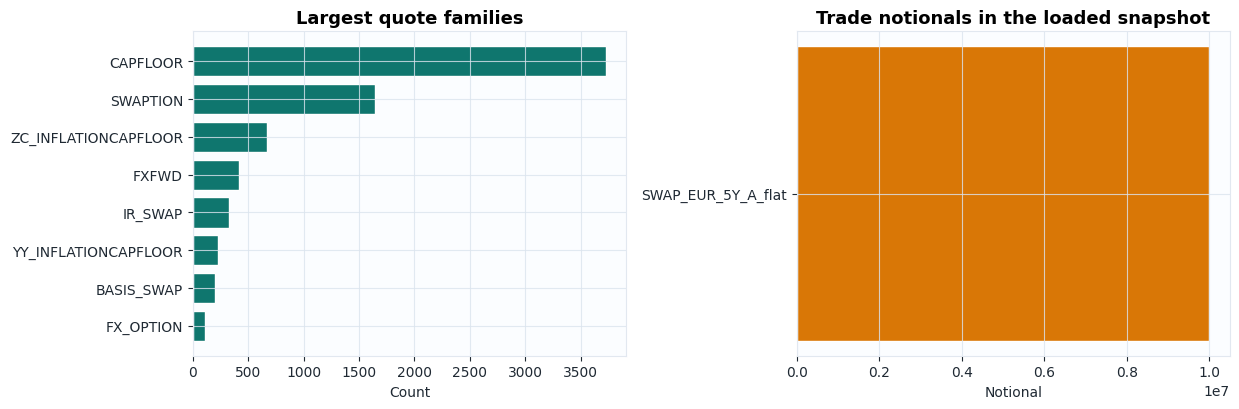

In [9]:
trade_df = nh.trade_frame(snapshot)
display(trade_df.head(12))
display(nh.netting_frame(snapshot).head(12))
display(nh.collateral_frame(snapshot).head(12))

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
nh.plot_ranked_bars(nh.quote_family_frame(snapshot), "family", "count", title="Largest quote families", color=nh.PALETTE["teal"], top_n=8, ax=axes[0])
nh.plot_ranked_bars(trade_df, "trade_id", "notional", title="Trade notionals in the loaded snapshot", color=nh.PALETTE["gold"], ax=axes[1])
plt.tight_layout()
plt.show()
plt.close(fig)


## Snapshot as a reusable artifact

The loader has already normalized XML, market text, fixings, and netting configuration into one object. That is the
practical value of the snapshot: most downstream code can stop caring which original file carried which piece.


{
  "collateral": {
    "balances": [],
    "source_meta": {
      "origin": "file",
      "path": "/Users/gordonlee/Documents/Engine/Tools/PythonOreRunner/notebook_series/_fresh_runs/notebook_02_1773231602000/Input/collateralbalances.xml"
    }
  },
  "config": {
    "analytics": [
      "CVA"
    ],
    "asof": "2016-02-05",
    "base_currency": "EUR",
    "horizon_years": 5,
    "num_paths": 5000,
    "params": {
      "asofDate": "2016-02-05",
      "calendarAdjustment": "/Users/gordonlee/Documents/Engine/Examples/Input/calendaradjustment.xml",
      "continueOnError": "false",
      "conventionsFile": "/Users/gordonlee/Documents/Engine/Examples/Input/conventions.xml",
      "curveConfigFile": "/Users/gordonlee/Documents/Engine/Examples/Input/curveconfig.xml",
      "fixingDataFile": "/Users/gordonlee/Documents/Engine/Examples/Input/fixings_20160205.txt",
      "implyTodaysFixings": "Y",
      "inputPath": "/Users/gordonlee/Documents/Engine/Tools/PythonOreRunner/parity_artifacts/mu

,field,value
0,asof,2016-02-05
1,base_currency,EUR
2,analytics,CVA
3,market_data_lines,7881
4,fixing_data_lines,5454
5,xml_buffers,8


,xml_name,chars,root_tag
0,collateralbalances.xml,42,CollateralBalances
1,conventions.xml,52729,Conventions
2,curveconfig.xml,131522,CurveConfiguration
3,netting.xml,3428,NettingSetDefinitions
4,portfolio.xml,2042,Portfolio
5,pricingengine.xml,15298,PricingEngines
6,simulation.xml,2210,Simulation
7,todaysmarket.xml,13743,TodaysMarket


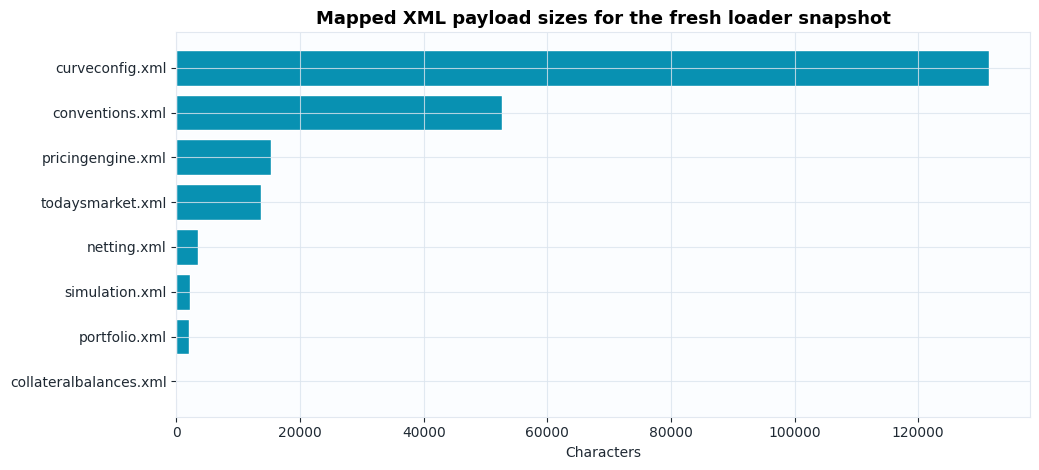

In [10]:
snapshot_dict = snapshot.to_dict()
snapshot_json = nh.to_pretty_json(snapshot_dict, limit=1800)
print(snapshot_json)

display(nh.mapped_input_summary(mapped))
display(nh.xml_buffer_summary(mapped).head(12))
nh.plot_xml_buffer_sizes(mapped, title="Mapped XML payload sizes for the fresh loader snapshot")


## Parity completeness audit

A runtime snapshot being usable is not the same thing as a case being parity-ready. The `OreSnapshot` audit is more
strict: it checks whether the run captured enough schedule, curve, credit, funding, and exposure information for a
fair Python-vs-ORE comparison.


,section,field,value
0,trade_setup,complete,True
1,trade_setup,fixed_leg_count,5
2,trade_setup,float_leg_count,10
3,curve_setup,complete,True
4,curve_setup,discount_column,EUR-EONIA
5,curve_setup,forward_column,EUR-EURIBOR-6M
6,curve_setup,xva_discount_column,EUR-EURIBOR-6M
7,curve_setup,borrowing_curve_column,None
8,curve_setup,lending_curve_column,None
9,curve_setup,discount_points,241


Parity issues: []
Parity ready: True


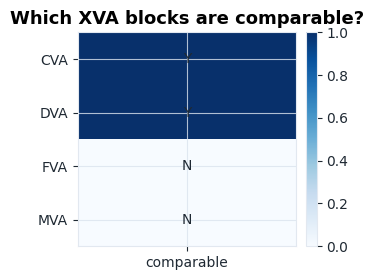

In [11]:
if ore_snapshot is not None:
    parity_report = ore_snapshot.parity_completeness_report()
    parity_df = ore_snapshot.parity_completeness_dataframe()
    display(parity_df)
    print("Parity issues:", parity_report["issues"])
    print("Parity ready:", parity_report["parity_ready"])
    comparability_df = parity_df[parity_df["section"] == "comparability"].copy()
    comparability_df["comparable"] = comparability_df["value"].astype(bool)
    nh.plot_boolean_matrix(comparability_df, row_col="field", value_cols=["comparable"], title="Which XVA blocks are comparable?")
else:
    print("No parity-grade OreSnapshot audit available for this loader bundle.")


The audit table is the one to trust when you want to compare engines. It separates “the case runs” from “the case is
economically lined up well enough to compare specific XVA numbers.”


In [12]:
# One cheap engine pass shows that the fresh snapshot is immediately executable from Python.
toy_result, toy_elapsed = nh.run_adapter(snapshot, DeterministicToyAdapter())
print(f"Deterministic toy run elapsed: {toy_elapsed:.4f}s")
display(nh.result_metrics_frame(toy_result))


Deterministic toy run elapsed: 0.0229s


,metric,value
0,PV,499931.553730
1,CVA,2219.712526
2,XVA_TOTAL,2219.712526


## Key takeaways

- The snapshot is the cleanest inspection boundary in the current Python-facing stack.
- Fresh ORE output generation removes the ambiguity of stale checked-in files.
- The parity audit is the right place to decide what can be compared, not an afterthought.

## Where this connects next

The next notebook zooms into the market side: curve extraction, curve fitting, and how those outputs feed the LGM model.
